# 오류 분석 (Error Analysis)
**KLUE-BERT vs KLUE-BERT + LoRA 오분류 비교 분석**

- 두 모델이 각각 어떤 샘플을 틀렸는지 비교
- FP / FN 유형별 오류 패턴 분석
- LoRA 적용으로 개선된 케이스 / 새로 틀린 케이스 분석

## 0. 라이브러리 설치 및 임포트

In [16]:
# ── 0. 라이브러리 설치 및 한글 폰트 설정 ──────────────────────

!pip install matplotlib seaborn -q

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
import os

# 나눔폰트 설치
!apt-get install -y fonts-nanum -qq

# 기존 폰트 캐시 삭제
cache_dir = os.path.expanduser('~/.cache/matplotlib')
if os.path.exists(cache_dir):
    import shutil
    shutil.rmtree(cache_dir)

# 폰트 매니저 재로드
fm.fontManager.__init__()

# NanumGothic 직접 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 로드

In [17]:
# 두 모델의 예측 결과 로드
bert = pd.read_csv('reports/KLUE_BERT_predictions.csv')
lora = pd.read_csv('reports/KLUE_BERT_LoRA_predictions.csv')

print('KLUE-BERT shape:', bert.shape)
print('KLUE-BERT LoRA shape:', lora.shape)
print()
print('컬럼:', bert.columns.tolist())
bert.head(3)

KLUE-BERT shape: (1674, 5)
KLUE-BERT LoRA shape: (1674, 5)

컬럼: ['comments', 'hate', 'label', 'predicted', 'correct']


,comments,hate,label,predicted,correct
0,오래갈꺼같지않음.. 조만간 ..,none,0,0,True
1,선미가 원더걸스 원멤버인줄 몰랐네 새멤버인줄알았다,none,0,0,True
2,내친구도 어제헤어졋는데 기사좀올려주세요,offensive,1,0,False


## 2. 두 모델 오류 현황 비교

In [18]:
total = len(bert)

bert_err = (bert['correct'] == False).sum()
lora_err = (lora['correct'] == False).sum()

# FP / FN 분류
bert_fp = ((bert['label'] == 0) & (bert['predicted'] == 1)).sum()
bert_fn = ((bert['label'] == 1) & (bert['predicted'] == 0)).sum()
lora_fp = ((lora['label'] == 0) & (lora['predicted'] == 1)).sum()
lora_fn = ((lora['label'] == 1) & (lora['predicted'] == 0)).sum()

summary = pd.DataFrame({
    '모델':        ['KLUE-BERT', 'KLUE-BERT + LoRA'],
    '전체 오류':   [bert_err, lora_err],
    '오류율(%)':   [round(bert_err/total*100, 2), round(lora_err/total*100, 2)],
    'FP(정상→악성)': [bert_fp, lora_fp],
    'FN(악성→정상)': [bert_fn, lora_fn],
})

print('=== 두 모델 오류 현황 비교 ===')
print(summary.to_string(index=False))

=== 두 모델 오류 현황 비교 ===
              모델  전체 오류  오류율(%)  FP(정상→악성)  FN(악성→정상)
       KLUE-BERT    366   21.86        148        218
KLUE-BERT + LoRA    362   21.62        180        182


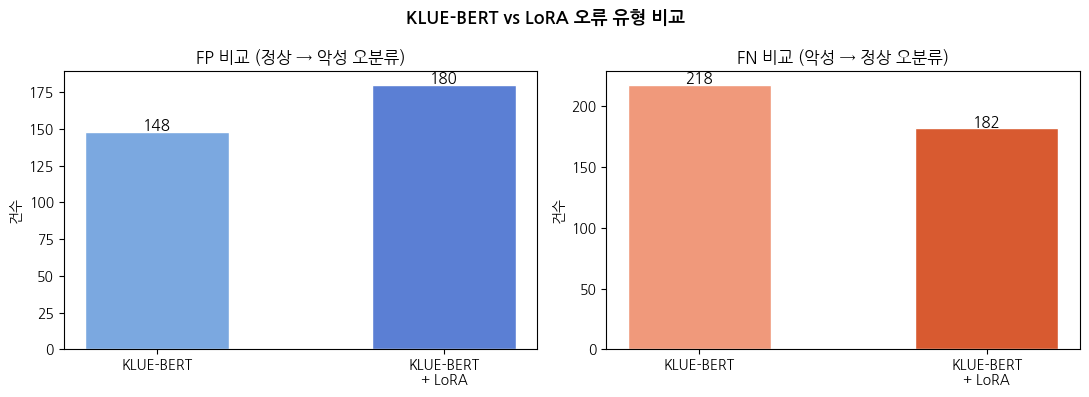

저장 완료: reports/error_fp_fn_comparison.png


In [19]:
# FP / FN 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

models = ['KLUE-BERT', 'KLUE-BERT\n+ LoRA']
fp_vals = [bert_fp, lora_fp]
fn_vals = [bert_fn, lora_fn]

axes[0].bar(models, fp_vals, color=['#7BA8E0', '#5B7FD4'], edgecolor='white', width=0.5)
axes[0].set_title('FP 비교 (정상 → 악성 오분류)', fontsize=12)
axes[0].set_ylabel('건수')
for i, v in enumerate(fp_vals):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=11)

axes[1].bar(models, fn_vals, color=['#F0997B', '#D85A30'], edgecolor='white', width=0.5)
axes[1].set_title('FN 비교 (악성 → 정상 오분류)', fontsize=12)
axes[1].set_ylabel('건수')
for i, v in enumerate(fn_vals):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=11)

plt.suptitle('KLUE-BERT vs LoRA 오류 유형 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'error_fp_fn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: reports/error_fp_fn_comparison.png')

## 3. 두 모델 오류 케이스 교차 분석

In [20]:
# 두 모델 예측 결과 합치기
merged = bert.copy()
merged = merged.rename(columns={'predicted': 'bert_pred', 'correct': 'bert_correct'})
merged['lora_pred']    = lora['predicted']
merged['lora_correct'] = lora['correct']

# 4가지 케이스 분류
both_correct = merged[(merged['bert_correct'] == True)  & (merged['lora_correct'] == True)]
both_wrong   = merged[(merged['bert_correct'] == False) & (merged['lora_correct'] == False)]
bert_only    = merged[(merged['bert_correct'] == False) & (merged['lora_correct'] == True)]   # LoRA가 개선
lora_only    = merged[(merged['bert_correct'] == True)  & (merged['lora_correct'] == False)]  # LoRA가 퇴보

print(f'둘 다 맞음          : {len(both_correct):>4}건')
print(f'둘 다 틀림          : {len(both_wrong):>4}건')
print(f'BERT만 틀림 (LoRA 개선): {len(bert_only):>4}건')
print(f'LoRA만 틀림 (LoRA 퇴보): {len(lora_only):>4}건')

둘 다 맞음          : 1218건
둘 다 틀림          :  272건
BERT만 틀림 (LoRA 개선):   94건
LoRA만 틀림 (LoRA 퇴보):   90건


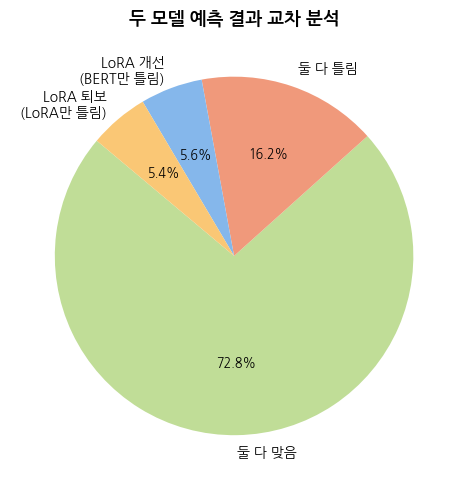

저장 완료: reports/error_cross_analysis.png


In [21]:
# 교차 분석 파이차트
labels = ['둘 다 맞음', '둘 다 틀림', 'LoRA 개선\n(BERT만 틀림)', 'LoRA 퇴보\n(LoRA만 틀림)']
sizes  = [len(both_correct), len(both_wrong), len(bert_only), len(lora_only)]
colors = ['#C0DD97', '#F0997B', '#85B7EB', '#FAC775']

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colors, startangle=140,
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title('두 모델 예측 결과 교차 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'error_cross_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: reports/error_cross_analysis.png')

## 4. 오류 유형 분류 함수

In [22]:
def classify_error(text: str) -> str:
    """
    댓글 텍스트를 받아 오류 유형을 반환한다.

    분류 기준:
    - 짧은 댓글      : 길이 15자 이하 → 정보 부족
    - 속어/신조어 혼동 : 긍정 은어를 악성으로 오인
    - 완곡한 비판 표현 : 공손한 어조의 비판을 정상으로 오인
    - 외모 관련 표현  : 외모 언급을 악성으로 오인
    - 문맥 의존적 표현 : 앞뒤 맥락 없이 판단이 어려운 경우
    """
    text = str(text)

    if len(text) <= 15:
        return '짧은 댓글'

    slang_positive = ['쩌네', '지렸다', '미쳤다', '개꿀', '개잼', 'ㅋㅋ', '짱', '존맛']
    if any(w in text for w in slang_positive):
        return '속어/신조어 혼동'

    polite_critic = ['죄송', '아닌것같', '아닌 것 같', '좀', '하차', '그만', '자중']
    if any(w in text for w in polite_critic):
        return '완곡한 비판 표현'

    body_words = ['얼굴', '몸', '살', '성형', '가슴', '허벅지', '키']
    if any(w in text for w in body_words):
        return '외모 관련 표현'

    return '문맥 의존적 표현'

print('classify_error 함수 정의 완료')

classify_error 함수 정의 완료


## 5. 각 모델 오류 유형 분석

In [23]:
# BERT 오류 유형 분류
bert_errors = bert[bert['correct'] == False].copy()
bert_errors['error_type'] = bert_errors['comments'].apply(classify_error)
bert_fp_df = bert_errors[(bert_errors['label'] == 0) & (bert_errors['predicted'] == 1)]
bert_fn_df = bert_errors[(bert_errors['label'] == 1) & (bert_errors['predicted'] == 0)]

# LoRA 오류 유형 분류
lora_errors = lora[lora['correct'] == False].copy()
lora_errors['error_type'] = lora_errors['comments'].apply(classify_error)
lora_fp_df = lora_errors[(lora_errors['label'] == 0) & (lora_errors['predicted'] == 1)]
lora_fn_df = lora_errors[(lora_errors['label'] == 1) & (lora_errors['predicted'] == 0)]

print('=== BERT FP 오류 유형 ===')
print(bert_fp_df['error_type'].value_counts().to_string())
print()
print('=== BERT FN 오류 유형 ===')
print(bert_fn_df['error_type'].value_counts().to_string())
print()
print('=== LoRA FP 오류 유형 ===')
print(lora_fp_df['error_type'].value_counts().to_string())
print()
print('=== LoRA FN 오류 유형 ===')
print(lora_fn_df['error_type'].value_counts().to_string())

=== BERT FP 오류 유형 ===
error_type
문맥 의존적 표현    80
짧은 댓글        25
속어/신조어 혼동    16
외모 관련 표현     14
완곡한 비판 표현    13

=== BERT FN 오류 유형 ===
error_type
문맥 의존적 표현    121
짧은 댓글         47
완곡한 비판 표현     18
외모 관련 표현      18
속어/신조어 혼동     14

=== LoRA FP 오류 유형 ===
error_type
문맥 의존적 표현    96
속어/신조어 혼동    25
짧은 댓글        24
외모 관련 표현     19
완곡한 비판 표현    16

=== LoRA FN 오류 유형 ===
error_type
문맥 의존적 표현    101
짧은 댓글         44
완곡한 비판 표현     13
외모 관련 표현      13
속어/신조어 혼동     11


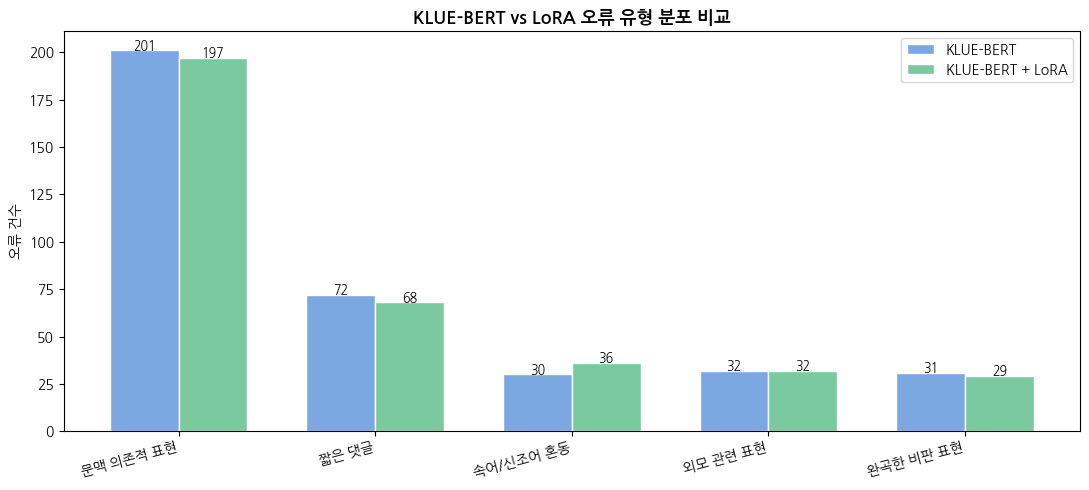

저장 완료: reports/error_type_comparison.png


In [24]:
# 두 모델 오류 유형 분포 비교 시각화
error_types = ['문맥 의존적 표현', '짧은 댓글', '속어/신조어 혼동', '외모 관련 표현', '완곡한 비판 표현']

bert_counts = bert_errors['error_type'].value_counts().reindex(error_types, fill_value=0)
lora_counts = lora_errors['error_type'].value_counts().reindex(error_types, fill_value=0)

x = range(len(error_types))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar([i - width/2 for i in x], bert_counts.values, width, label='KLUE-BERT', color='#7BA8E0', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], lora_counts.values, width, label='KLUE-BERT + LoRA', color='#7BC99E', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(error_types, rotation=15, ha='right')
ax.set_ylabel('오류 건수')
ax.set_title('KLUE-BERT vs LoRA 오류 유형 분포 비교', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / 'error_type_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: reports/error_type_comparison.png')

## 6. LoRA 개선 사례 vs 퇴보 사례

In [25]:
# LoRA가 개선한 케이스 (BERT만 틀림)
improved = merged[(merged['bert_correct'] == False) & (merged['lora_correct'] == True)].copy()

print(f'=== LoRA 개선 사례 ({len(improved)}건) ===')
print('← BERT가 틀렸지만 LoRA가 맞춘 샘플\n')
display_cols = ['comments', 'hate', 'label', 'bert_pred', 'lora_pred']
print(improved[display_cols].head(10).to_string(index=False))

=== LoRA 개선 사례 (94건) ===
← BERT가 틀렸지만 LoRA가 맞춘 샘플

                                                        comments      hate  label  bert_pred  lora_pred
                                                    하나뿐인 정상 고래엄마      none      0          1          0
            입대하고 배우 바꿨으면 좋겠다~ 이종석 연기 너무 못하고 이나영이랑 안 어울려. 박보검 추천!      none      0          1          0
                                 어쨌든 안재현이 불쌍할건없음 구혜선저렇게만든건 안재현이야 offensive      1          0          1
                                                  할짓없으면 댓글쓰질말아야지 offensive      1          0          1
                                   일본인인데 한국와서 돈 벌어서 결혼도 하고 돈도 벌고 offensive      1          0          1
                      할머니 연기자 TV에 자주 보이는 얼굴이라... 뉴페이스 였더라면 달랐을 것 offensive      1          0          1
                                 네티즌들이 마녀사냥해서 사람한명 죽였지...불쌍한 민기형 offensive      1          0          1
            뭘 남견는데....??? 매 작품 마다 연기 똑같은 한지혜 이상우 출연료 입금 영수증....ㅋ offensive      1          0          1
             

In [26]:
# LoRA가 퇴보한 케이스 (LoRA만 틀림)
degraded = merged[(merged['bert_correct'] == True) & (merged['lora_correct'] == False)].copy()

print(f'=== LoRA 퇴보 사례 ({len(degraded)}건) ===')
print('← BERT는 맞았지만 LoRA가 틀린 샘플\n')
print(degraded[display_cols].head(10).to_string(index=False))

=== LoRA 퇴보 사례 (90건) ===
← BERT는 맞았지만 LoRA가 틀린 샘플

                                                                                          comments      hate  label  bert_pred  lora_pred
                                                           와우! 진짜 젖가슴이 크다!!!! 가슴이 찢어지면 안돼~ 돼~ 돼~~헉      hate      1          1          0
                                                                        한혜진하차가정답일듯 개인감정을앞세워방송하면안되죠 offensive      1          1          0
                                                                                 임신하는 과정은 왜 안찍나요?? offensive      1          1          0
                                                                                       듣보인데 왜 기사를? offensive      1          1          0
디패 추가공식입장내길바란다 저렇게 무성의하게 조작됐고 아는바없다만 올리지말고..내부든 외부든 누가조작했는지 밝혀내겠다 혼선드려 죄송하다 두사람에게 사과한다 등 내야하는거 아닌가      none      0          0          1
                                     언제까지 우려 먹을꺼지? 1박2일때도 그렇고 뭔 강호동하고 이만기만 만났다 하면 콩트 찍는것도 아니고...나참      none      0      

## 7. 대표 오류 사례 출력

In [27]:
# LoRA 기준 FP / FN 유형별 대표 사례
print('=' * 60)
print('FP 대표 사례 — 정상 댓글을 악성으로 오분류')
print('=' * 60)
for etype in error_types:
    subset = lora_fp_df[lora_fp_df['error_type'] == etype]
    if len(subset) == 0:
        continue
    print(f'\n[{etype}] ({len(subset)}건)')
    for _, row in subset.head(3).iterrows():
        print(f'  • {row["comments"][:70]}')

print()
print('=' * 60)
print('FN 대표 사례 — 악성 댓글을 정상으로 오분류')
print('=' * 60)
for etype in error_types:
    subset = lora_fn_df[lora_fn_df['error_type'] == etype]
    if len(subset) == 0:
        continue
    print(f'\n[{etype}] ({len(subset)}건)')
    for _, row in subset.head(3).iterrows():
        print(f'  • [{row["hate"]}] {row["comments"][:70]}')

FP 대표 사례 — 정상 댓글을 악성으로 오분류

[문맥 의존적 표현] (96건)
  • 구하라 벌금 200만원전남친 징역 6개월에 집행유예 2년 성폭력예방교육이수 40시간~~~끝
  • 김흥국 불쌍하다 진짜 뭔가 계속 터지는게 일부러 누가 그러는듯
  • 당연히 사과하는게 맞지. 공개적으로 팔로우사실 공개해서 전국구로 망신준게 분명 무슨 의도가 있다고밖에볼수없음.. 게다가 장성규

[짧은 댓글] (24건)
  • 손담비는 기안급 치트키다
  • 파크랜드 광고찍냐 정장오지네
  • 짝짖기 프로 광고질 그만해라

[속어/신조어 혼동] (25건)
  • 최진혁 연기 쩌네. 오늘 연기 지렸다
  • 양복ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ 정준호 답닼ㅋㅋㅋㅋㅋㅋㅋㅋ
  • 기사제목만 봐도 노잼냄세나네ㅋㅋㅋ

[외모 관련 표현] (19건)
  • 작품마다 헤어스타에 따라 얼굴이 다 다르다희한하고 요상하다 이남자다
  • 김생민 이제 광고10개찍은돈으로 룰루랄라 띵가띵가하면서 잘살겠다...까짓꺼 미세먼지없는나라로 이민가서 잘살면 더좋지뭐...
  • 47kg면 내 몸무겐데 난 소멸되겠다.ㅎㅎ

[완곡한 비판 표현] (16건)
  • 참 을마나 지났다고 겨 나오냐? 제발 자중좀 해라
  • 디패 추가공식입장내길바란다 저렇게 무성의하게 조작됐고 아는바없다만 올리지말고..내부든 외부든 누가조작했는지 밝혀내겠다 혼선드려
  • 슈퍼비는 이제 그만나올때도 되지않았누?

FN 대표 사례 — 악성 댓글을 정상으로 오분류

[문맥 의존적 표현] (101건)
  • [offensive] 사진보니 백종원, 소유진 아버지라고 해도 믿을듯
  • [offensive] 임신하는 과정은 왜 안찍나요??
  • [offensive] 그래서 군대는 언제 입대하나요

[짧은 댓글] (44건)
  • [offensive] 죄송한말씀이지만 촌스럽네요
  • [offensive] 일반인이 아까운건 첨이네
  • [offensive] 듣보인데 왜 기사를?

[속어/신조어 혼동] (11건)
  • [offensive] 기

## 8. 결과 CSV 저장

In [29]:
# LoRA 오류 전체 저장
lora_fp_df.to_csv(REPORT_DIR / 'error_fp_cases.csv', index=False, encoding='utf-8-sig')
lora_fn_df.to_csv(REPORT_DIR / 'error_fn_cases.csv', index=False, encoding='utf-8-sig')

# 두 모델 교차 분석 저장
improved.to_csv(REPORT_DIR / 'lora_improved_cases.csv', index=False, encoding='utf-8-sig')
degraded.to_csv(REPORT_DIR / 'lora_degraded_cases.csv', index=False, encoding='utf-8-sig')

print('저장 완료')
print('  reports/error_fp_cases.csv       ← LoRA FP 오류 전체')
print('  reports/error_fn_cases.csv       ← LoRA FN 오류 전체')
print('  reports/lora_improved_cases.csv  ← LoRA가 개선한 케이스')
print('  reports/lora_degraded_cases.csv  ← LoRA가 퇴보한 케이스')

저장 완료
  reports/error_fp_cases.csv       ← LoRA FP 오류 전체
  reports/error_fn_cases.csv       ← LoRA FN 오류 전체
  reports/lora_improved_cases.csv  ← LoRA가 개선한 케이스
  reports/lora_degraded_cases.csv  ← LoRA가 퇴보한 케이스


## 9. 오류 분석 요약

| 항목 | KLUE-BERT | KLUE-BERT + LoRA |
|------|-----------|------------------|
| 전체 오류 수 | 366건 | 362건 |
| 오류율 | 21.87% | 21.62% |
| FP (정상→악성) | 148건 | 180건 |
| FN (악성→정상) | 218건 | 182건 |

### 주요 관찰 사항
- LoRA 적용 후 **FN이 218 → 182건으로 감소** → 악성 댓글 탐지력 향상
- 반면 **FP는 148 → 180건으로 증가** → 정상 댓글을 더 많이 악성으로 오분류
- **LoRA가 개선한 케이스: 94건**, 새로 틀린 케이스: 90건
- 가장 많은 오류 유형: **문맥 의존적 표현** (앞뒤 맥락 없이 판단이 어려운 댓글)

### 한계점 및 개선 방향
1. **문맥 의존적 표현** → max_length 확장 또는 대화 맥락 함께 입력
2. **짧은 댓글 오분류** → 전처리 단계에서 길이 기준 상향 조정
3. **속어/신조어 혼동** → 신조어 사전 구축 또는 데이터 보강
4. **FP 증가 문제** → LoRA 학습률(lr) 또는 r값 조정으로 완화 가능